# Chapter 3 - Convolutional Neural Networks (CNNs)

### Loading "MNIST" to PyTorch

In [3]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from idlmam import *
from sklearn.metrics import accuracy_score

In [5]:
# Downloading the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())


In [7]:
# Verify data as tensor
x_example, y_example = mnist_data_train[0]
print(type(x_example))
print(x_example.shape)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])


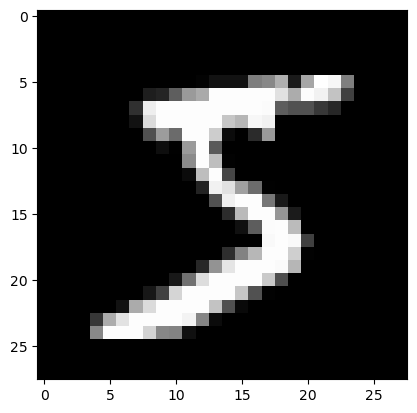

In [8]:
# Image visualization with "imsho"
plt.imshow(x_example[0,:], cmap='gray')

In [5]:
# Add 3 dimensions for Channels
x_as_color = torch.stack([x_example[0,:], x_example[0,:], x_example[0,:]], dim=0)
print(x_as_color.shape)

torch.Size([3, 28, 28])


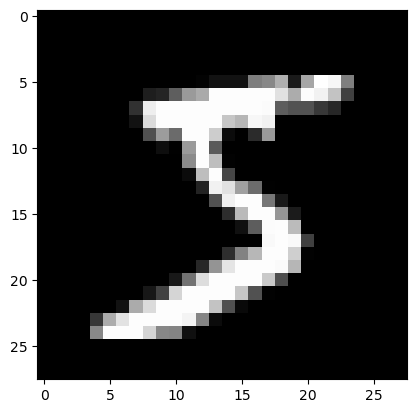

In [6]:
# permute images in imshow
plt.imshow(x_as_color.permute(1,2,0))

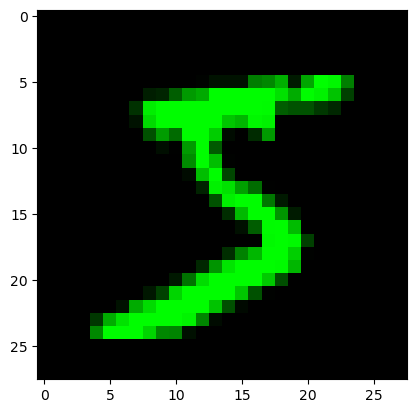

In [10]:
# Zero out the red and blue channels to get a green image
x_as_color = torch.stack([x_example[0,:], x_example[0,:], x_example[0,:]])
x_as_color[0,:] = 0
x_as_color[2,:] = 0
plt.imshow(x_as_color.permute(1,2,0))

Mix several images of different colors to see the difference in representation using torch.stack

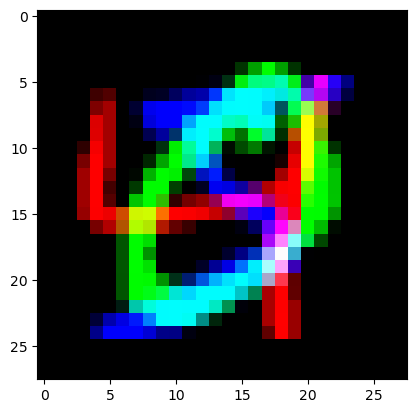

In [ ]:
# Using a 5 (blue), 4 (red) and 0 (green)
x1, x2, x3 = mnist_data_train[0], mnist_data_train[1], mnist_data_train[2]
x1, x2, x3 = x1[0], x2[0], x3[0]
x_as_color = torch.stack([x3[0,:], x2[0,:], x1[0,:]], dim=0)
plt.imshow(x_as_color.permute(1,2,0))

Shuffling the data from the number "5" to see the impact

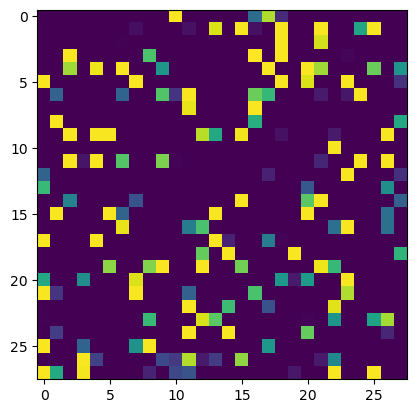

In [22]:
random_order = torch.randperm(x_example.shape[1] * x_example.shape[2])
x_shuffled = x_example.view(-1)[random_order].view(x_example.shape)
plt.imshow(x_shuffled[0,:])

## Definition of Convolutions
Convolution is a mathematical function with two inputs: an "image" an a "filter" (kernel) and ouput a new image. The purpose of a convolution filter is to recognize patterns in an given image.

The Spatial relationship: "Things near each other are related, and things far from each other have no relationship"

### 1D Convolutions (C,W) shape
Examples

In [30]:
# 1D input with filter size K=1 (1 dimension)
filter =[1, 0, -1]
input = [1, 0, 2, -1, 1, 2]
output = []

for i in range(len(input)-len(filter)+1):
    result = 0
    for j in range (len(filter)):
        result += input[i+j]*filter[j]
    output.append(result)

print(output)

[-1, 1, 1, -3]


### 2D Convolutions (C,W) K=3

In [ ]:
# 2D input with a filter size K=3 (3 dimensions)
filter = [[0,1,0],
          [0,1,0],
          [0,1,0]]

input = [[0,0,1,1,0,0],
         [0,1,0,1,0,0],
         [0,0,0,1,0,0],
         [0,0,0,1,0,0],
         [0,0,0,1,1,0],
         [0,1,1,1,1,1]]

height, width = len(input), len(input[0])
output = []

for i in range(height-len(filter) + 1): # slides filter over rows
    row_out = []
    for j in range(width-len(filter) + 1): # slides filter over columns
        result = 0
        for k_i in range(len(filter)): # applies filter at this location
            for k_j in range(len(filter)):
                result += input[i+k_i][j+k_j]*filter[k_i][k_j]
            
        row_out.append(result)
    output.append(row_out)

output

[[1, 1, 3, 0], [1, 0, 3, 0], [0, 0, 3, 1], [1, 1, 3, 2]]

### Convolutions in image processing

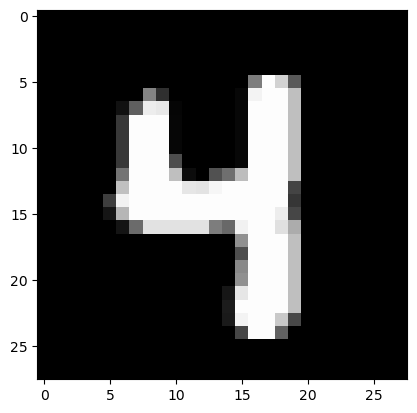

In [5]:
from scipy.signal import convolve
img_indx = 58
img = mnist_data_train[img_indx][0][0,:]
plt.imshow(img, vmin=0, vmax=1, cmap='gray')

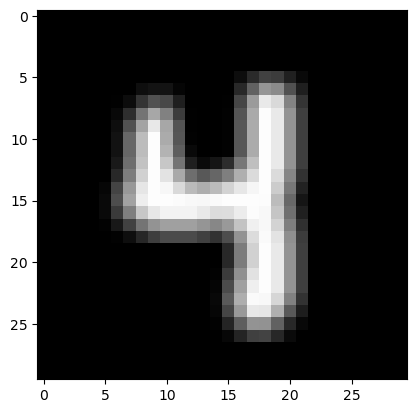

In [7]:
# Getting a blurry image with a filter
blur_filter = np.asarray([[1,1,1],
                          [1,1,1],
                          [1,1,1]])/9.0

blurry_image = convolve(img, blur_filter)
plt.imshow(blurry_image, vmin=0, vmax=1, cmap='gray')


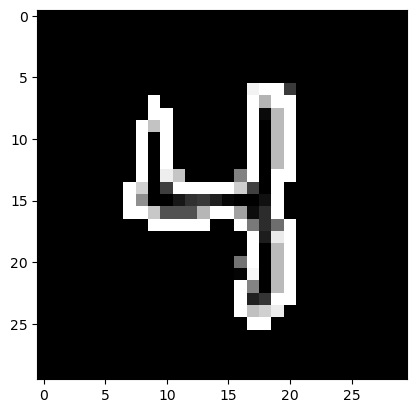

In [8]:
# Applyin an edge kernel.
edge_filter = np.asarray([[-1,-1,-1],
                          [-1, 8,-1],
                          [-1,-1,-1]])

edge_image = convolve(img, edge_filter)
plt.imshow(edge_image, vmin=0, vmax=1, cmap='gray')

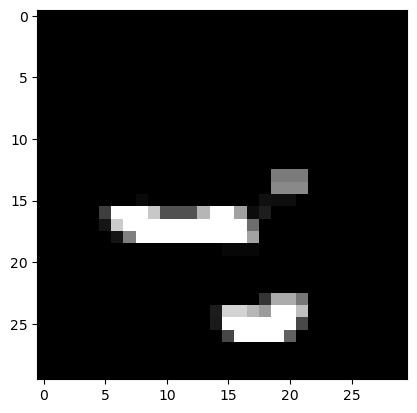

In [11]:
# applying a 3x3 kernel to find horizontal edges
h_edge_filter = np.asarray([[-1,-1,-1],
                            [ 0, 0, 0],
                            [ 1, 1, 1]])

h_edge_image =  convolve(img, h_edge_filter)
plt.imshow(h_edge_image, vmin=0, vmax=1, cmap='gray')

### Creating my first Convolutional Neural Network (CNN)

In [13]:
# Verification of CUDA present
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [14]:
device

device(type='cuda')

In [ ]:
# Create a DataLoaders
B = 32 #Batch size
mnist_train_loader = DataLoader(mnist_data_train, batch_size=B, shuffle=True)
mnist_test_loader = DataLoader(mnist_data_test, batch_size=B)

In [15]:
# CREATING THE CNN MODEL

# Determine de layers of subsequent layers
D = 28*28
# Channels in the input (1 for grayscale)
C = 1
# Number of classes
classes = 10
# Number of filters used
filters = 16
# filters size
K = 3

# Define a linear model for comparison
model_linear = nn.Sequential(
    nn.Flatten(), # (B, C, W, H) -> (B, C*W*H) = (B, D)
    nn.Linear(D, 256),
    nn.Tanh(),
    nn.Linear(256, classes)
)

# Now the simple CNN. Conv2d
model_cnn = nn.Sequential(
    nn.Conv2d(C, filters, K, padding=K//2), # x(conv)D
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(filters*D, classes)
)

In [18]:
# TRAINING THE MODELS

from sklearn.metrics import accuracy_score
# Define Loss Function
loss_func = nn.CrossEntropyLoss()

# FULLY CONNECTED MODEL
fc_results = train_simple_network(model_linear, loss_func,
                                  mnist_train_loader, test_loader=mnist_test_loader,
                                  score_funcs={'Accuracy': accuracy_score},
                                  device=device,
                                  epochs=20)

Epoch: 100%|██████████| 20/20 [03:20<00:00, 10.03s/it]


In [19]:
# CNN MODEL
cnn_results = train_simple_network(model_cnn, loss_func,
                                   mnist_train_loader,
                                   test_loader=mnist_test_loader,
                                   score_funcs={'Accuracy': accuracy_score},
                                   device=device,
                                   epochs=20)


Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 100%|██████████| 20/20 [03:25<00:00, 10.26s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

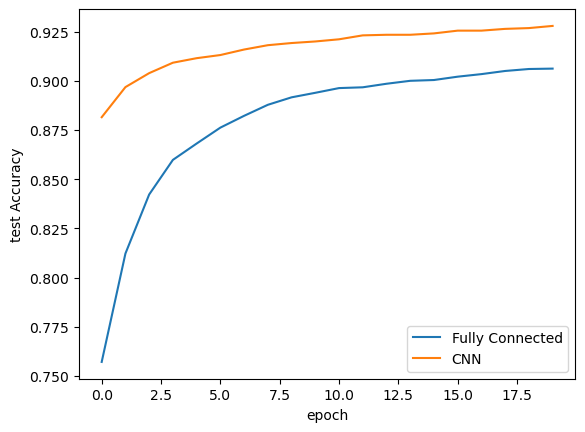

In [20]:
# COMPARE MODELS

sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Connected')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')

### Adding Pooling to CNN to mitigate object movement

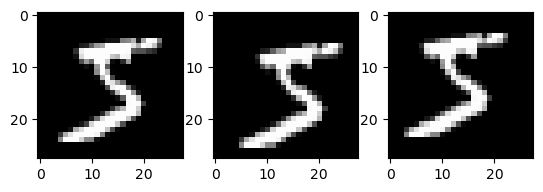

In [11]:
# Create MNIST images moved 1 pixel up and down
img_indx = 0
img, correct_class = mnist_data_train[img_indx]
img = img[0,:]
img_lr = np.roll(np.roll(img, 1, axis=1), 1, axis=0)
img_ul = np.roll(np.roll(img, -1, axis=1), -1, axis=0)

f, axrr = plt.subplots(1, 3)
axrr[0].imshow(img, cmap='gray')
axrr[1].imshow(img_lr, cmap='gray')
axrr[2].imshow(img_ul, cmap='gray')


In [24]:
# Evaluate the model using "eval()" and create a function to get predictions for a single image

# Evaluation mode:
model =  model_cnn.cpu().eval()

# TURN OFF gradients when evaluating. The function takes the model and 1 image input
def pred(model, img):
    with torch.no_grad():
        # finds the width/height of the image
        w, h = img.shape
    
        # Reshapes as (B, C, W, H)
        if not isinstance(img, torch.Tensor):
            img = torch.tensor(img)
        x = img.reshape(1, -1, w, h)

        # Gets the logits
        logits = model(x)

        # Turns the logits into possibilities
        y_hat = F.softmax(logits, dim=1)

        # Converts the prediction to a NumpPy array
    return y_hat.numpy().flatten()


In [25]:
# Create the predictions
img_pred = pred(model, img)
img_lr_pred = pred(model, img_lr)
img_ul_pred = pred(model, img_ul)

print("Org Img Class {} Prob: ".format(correct_class), img_pred[correct_class])
print("Lower Right Img Class {} Prob: ".format(correct_class), img_lr_pred[correct_class])
print("Upper Left Img Class {} Prob: ".format(correct_class), img_ul_pred[correct_class])

Org Img Class 5 Prob:  0.778161
Lower Right Img Class 5 Prob:  0.40410995
Upper Left Img Class 5 Prob:  0.36860183


In [26]:
# The "TRANSLATION INVARIANCE" property of CNN partialy added by "MAX POOLING".

model_cnn_pool = nn.Sequential(
    nn.Conv2d(C, filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(filters, filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(filters, filters, 3, padding=3//2),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(filters, 2*filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
    nn.Tanh(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(2*filters*D//(4**2), classes)
)

In [27]:
# RESULTS
cnn_results_with_pool = train_simple_network(model_cnn_pool, loss_func,
                                             mnist_train_loader, 
                                             test_loader=mnist_test_loader,
                                             score_funcs={'Accuracy': accuracy_score},
                                             device=device,
                                             epochs=20)

Epoch: 100%|██████████| 20/20 [03:57<00:00, 11.89s/it]


In [28]:
# Create the predictions from pooled model
model = model_cnn_pool.cpu().eval()

# Using the pred function for predictions
img_pred = pred(model, img)
img_lr_pred = pred(model, img_lr)
img_ul_pred = pred(model, img_ul)

print("Org Img Class {} Prob: ".format(correct_class), img_pred[correct_class])
print("Lower Right Img Class {} Prob: ".format(correct_class), img_lr_pred[correct_class])
print("Upper Left Img Class {} Prob: ".format(correct_class), img_ul_pred[correct_class])

Org Img Class 5 Prob:  0.73283184
Lower Right Img Class 5 Prob:  0.84535927
Upper Left Img Class 5 Prob:  0.80109006


<Axes: xlabel='epoch', ylabel='test Accuracy'>

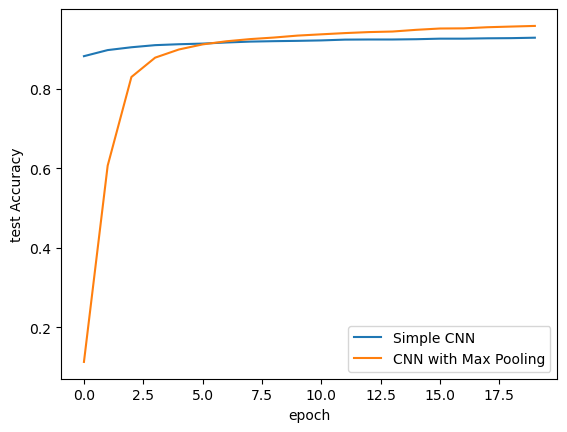

In [29]:
# Accuracy of the CNN pooled model

sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='Simple CNN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN with Max Pooling')

### Data Augmentation 
Creating new fake data based on real data. One way is applying transforms to the data which does not change the meaning of the content but alters the pixels.

Transformation examples:
- Rotation
- Translation
- Shear
- RandomCrop
- Horizontal Flip
- Vertical Flip
- Perspective
- ColorJitter

In PyTorch we use the `torchvision.transforms` package to create this changes

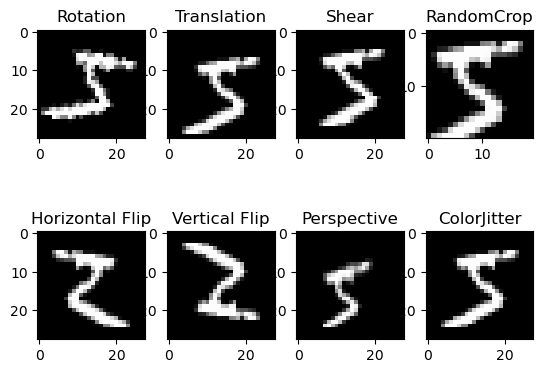

In [37]:
# Built-in transformations examples

sample_transforms = {
    'Rotation' : transforms.RandomAffine(degrees=45),
    'Translation' : transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    'Shear' : transforms.RandomAffine(degrees=0, shear=45),
    'RandomCrop' : transforms.RandomCrop((20,20)),
    'Horizontal Flip' : transforms.RandomHorizontalFlip(p=1.0),
    'Vertical Flip' : transforms.RandomVerticalFlip(p=1.0),
    'Perspective' : transforms.RandomPerspective(p=1.0),
    'ColorJitter' : transforms.ColorJitter(brightness=0.9, contrast=0.9)
}

# Converting the tensor image back to a PIL image using a transform
pil_img =  transforms.ToPILImage()(img)

# Plots a random application of each transform
f, axarr = plt.subplots(2,4)
for count, (name, t) in enumerate(sample_transforms.items()):
    row = count % 4
    col = count //4
    axarr[col, row].imshow(t(pil_img), cmap='gray')
    axarr[col, row].set_title(name)


In [41]:
# Usage of a sequenc of transformations using "transforms.Compose"
train_transform = transforms.Compose(
    [transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.98, 1.02)),
     transforms.ToTensor()]
)

test_transform = transforms.ToTensor()
mnist_train_t = torchvision.datasets.MNIST("./data", train=True, transform=train_transform)
mnist_test_t = torchvision.datasets.MNIST("./data", train=False, transform=test_transform)

mnist_train_loader_t = DataLoader(mnist_train_t, shuffle=True, batch_size=B, num_workers=6)
mnist_test_loader_t = DataLoader(mnist_test_t, batch_size=B, num_workers=6)

In [42]:
# Train the CNN_pooled with the transformed data from the DataLoader
cnn_results_with_pool_augmented = train_simple_network(model_cnn_pool,
                                                       loss_func,
                                                       mnist_train_loader_t,
                                                       test_loader=mnist_test_loader_t,
                                                       score_funcs={'Accuracy' : accuracy_score},
                                                       device=device,
                                                       epochs=20)

Epoch: 100%|██████████| 20/20 [03:44<00:00, 11.23s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

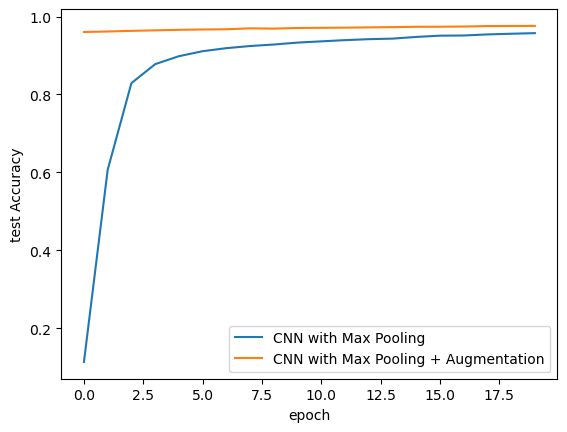

In [43]:
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN with Max Pooling')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool_augmented, label='CNN with Max Pooling + Augmentation')